# Deterministic-model verification: POD / FAR / SEDI maps

Global maps of **POD**, **FAR**, and **SEDI** for the deterministic
**AIFS-single-v2** reforecast
(`/net/monsoon/marchakitus/reforecast/forecasts_AIFS_v2`, opened via
`aifs_singlev2.open_aifs_singlev2()`) against ERA5, at lead days
**1, 3, 5, 7, 9**, over `test_year_start`-`test_year_end`.

**`test_year_start`/`test_year_end` and `region_bounds` (see the Step 0
config cell) are the two settings to change between runs** -- no separate
demo/full switch: set `region_bounds` to a small box (e.g. the Delhi, India
default) and/or a narrow year range for a fast run, or `region_bounds = None`
(or the environment variable `REGION_BOUNDS=global`) with a wide year range
for the real global/full-year thing. A small region keeps every step cheap
regardless of how many initializations it covers (Step 3 takes advantage of
this -- see there), so there's no need for anything beyond these two
settings to get a fast, representative run.

All of these (plus the dask cluster's `n_workers`/`threads_per_worker`/
`memory_limit`) can also be set from **outside** this notebook via
environment variables (`TEST_YEAR_START`, `TEST_YEAR_END`, `REGION_BOUNDS`,
`N_WORKERS`, `THREADS_PER_WORKER`, `MEMORY_LIMIT`) instead of editing the
Step 0 cells directly -- see `run_notebook.slurm`, which sets these before
regenerating and executing this notebook so a batch run's parameters live in
the Slurm submit script, not in this file.

*RMSE and the relative/climatology threshold are both commented out for
now* -- only the **absolute** threshold path actually runs this pass, since
that's all that's needed right now and skipping the climatology computation
(366 quantile reductions over 22 years of global data) removes by far the
most expensive part of the notebook.

Extreme-event variable: **daily-mean 2m air temperature** (`t2m_mean_6h`).
Threshold definition currently active:

- **Absolute**: `t2m_mean_6h > 35`degC.

(Commented out, not deleted, for whenever it's needed again: **Relative** --
`t2m_mean_6h` above the 97.5th percentile of local climatology, computed per
grid cell and calendar day from 2000-2021 ERA5, pooling a +/-15-day window
around each calendar day -- `climatology.local_climatology_quantile`.)

**Steps below, each runnable and inspectable on its own:**

0. Setup -- imports, config, dask cluster.
1. Load data -- raw model and ERA5 datasets, untouched.
2. Preprocess and align -- units, daily aggregation, spatial grid alignment.
3. Examine the variable of interest -- a small `model_var`/`era5_var` sample,
   before running anything expensive, to sanity-check the data makes sense.
4. Calculate H, M, F, C -- batched over initializations.
5. Calculate POD, FAR, SEDI.
6. Sanity checks -- range/consistency checks on the results themselves.
7. Plotting.

Self-contained: does not import the `heatextremes` package (a shared,
read-only dependency here) -- see `deterministic_metrics.py` and
`era5_loader.py` for the small amount of logic copied locally instead.

**Not executed in this environment:** this notebook needs `/net/monsoon/...`
and the real AIFS-single-v2/ERA5 data stores, neither of which is reachable
here, so cells below were written, unit-tested against synthetic arrays (see
the accompanying module tests), and syntax-checked, but not run end-to-end
against real data. In particular:

- `aifs_singlev2.open_aifs_singlev2()`'s glob pattern/chunking is adapted
  from the ensemble loader but not verified against the real store.
- The climatology computation (one quantile reduction per day of year, over
  22 years of global 0.25-degree daily data) is expensive; consider
  persisting `threshold_by_doy` to disk after computing it once, rather
  than recomputing it on every run.

## Step 0: Setup

Imports, configuration, and the dask cluster. The settings you'll actually
change between runs are `test_year_start`/`test_year_end` (inclusive; set
them equal for a single year, or apart for a multi-year run) and
`region_bounds` (a `(south, north, west, east)` box in degrees, or `None`
for the full global grid).

In [1]:
import csv
import os
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from zarr.errors import ZarrUserWarning

from era5_loader import open_cached_era5, daily_era5_aggregates  # local, no heatextremes dependency

from aifs_singlev2 import open_aifs_singlev2, daily_aifs_aggregates_calendar_aligned
# from climatology import local_climatology_quantile, threshold_at_verification_time  # not needed: absolute-only for now
from deterministic_metrics import (
    extreme_indicators,
    false_alarm_ratio,
    mean_in_time_batches,  # local copy, no heatextremes dependency -- see deterministic_metrics.py
    probability_of_detection,
    probability_of_false_detection,
    verification_time,  # used in Step 3 to find the ERA5 dates a model sample verifies against
    # rmse_from_mean_squared_error,  # RMSE commented out for now -- see calculate_scores/finish-metrics cells
    # squared_error,  # RMSE commented out for now -- see calculate_scores/finish-metrics cells
    symmetric_extremal_dependence_index,
)

# --- The settings you'll actually change between runs ---
# Each reads an environment variable first, falling back to the hardcoded
# default if that variable isn't set -- so a Slurm submit script can control
# these without editing this file (see run_notebook.slurm, which sets
# TEST_YEAR_START/TEST_YEAR_END/REGION_BOUNDS before generating this
# notebook). Editing the defaults below still works fine for interactive use.
test_year_start = int(os.environ.get("TEST_YEAR_START", 2022))
test_year_end = int(os.environ.get("TEST_YEAR_END", 2022))  # inclusive; > test_year_start for multi-year

# Region to restrict both model and ERA5 to, as (south, north, west, east) in
# degrees -- e.g. the Delhi, India default below. A small region keeps every
# step cheap regardless of how many initializations it covers (Step 3 takes
# advantage of this -- see there, and Step 2 for where this gets applied); a
# large or global region will be slow, especially Step 3's inspection and
# Step 4's batched pass.
#
# REGION_BOUNDS env var format: "south,north,west,east" (e.g.
# "27.5,29.5,76.5,78.5"), or the literal "global" for the full grid (None).
_region_bounds_env = os.environ.get("REGION_BOUNDS")
if _region_bounds_env is None:
    region_bounds = (27.5, 29.5, 76.5, 78.5)  # Delhi, India; set to None for global
elif _region_bounds_env.strip().lower() == "global":
    region_bounds = None
else:
    region_bounds = tuple(float(value) for value in _region_bounds_env.split(","))
    if len(region_bounds) != 4:
        raise ValueError(
            "REGION_BOUNDS must be 'south,north,west,east' or 'global', "
            f"got: {_region_bounds_env!r}"
        )

variable = "t2m_mean_6h"
forecast_days = 10  # daily aggregation covers lead days up to (and including) day 9
lead_days_to_plot = [1, 3, 5, 7, 9]
absolute_threshold = 35.0  # degC

# Human-readable tag for this region, used in cache/output filenames below so
# that changing region_bounds (without also changing test_year_start/end)
# can't silently reuse a cache file computed for a different region.
region_label = (
    "global" if region_bounds is None
    else "region_{:.2f}_{:.2f}_{:.2f}_{:.2f}".format(*region_bounds)
)

# Where the expensive per-lead-map result is cached, so re-running this notebook
# doesn't redo the full batching pass over all initializations. Filename includes
# both the year range and region_label, so a different region or year range never
# gets mistaken for (or overwrites) a previous result.
by_lead_map_cache_path = Path(
    f"aifs_singlev2_absolute_by_lead_map_{test_year_start}_{test_year_end}_{region_label}.nc"
)

# One row appended per run that actually computes (not loads from cache) -- see
# log_run_timing() in Step 4 -- so wall-clock time can be compared across cluster
# configurations / regions / year ranges over time.
run_timing_log_path = Path("run_timings.csv")

# Relative/climatology config -- unused while the relative threshold is commented out below.
# relative_percentile = 97.5  # of local climatology
# climatology_start_year = 2000
# climatology_end_year = 2021  # excludes the test range, so the climatology isn't built from the data it's scoring
# climatology_window_days = 15

In [2]:
from dask.distributed import Client, LocalCluster

# Named (not inlined) so Step 4 can log them alongside each run's wall-clock time,
# for comparing configurations later. Each also reads an environment variable
# first (see run_notebook.slurm, which derives these from the job's own
# --cpus-per-task/--mem so they can't silently drift out of sync with what
# Slurm actually granted).
n_workers = int(os.environ.get("N_WORKERS", 6))              # match the CPUs you requested
threads_per_worker = int(os.environ.get("THREADS_PER_WORKER", 1))
memory_limit = os.environ.get("MEMORY_LIMIT", "3GiB")  # tune to your node memory -- global, multi-decade
                                                        # data needs more than the small single-region demo
                                                        # this notebook started from

cluster = LocalCluster(
    n_workers=n_workers,
    threads_per_worker=threads_per_worker,
    processes=True,
    memory_limit=memory_limit,
)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 32,Total memory: 256.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37531,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37415,Total threads: 1
Dashboard: http://127.0.0.1:35563/status,Memory: 8.00 GiB
Nanny: tcp://127.0.0.1:33421,


## Step 1: Load data

Raw model and ERA5 datasets, untouched -- no unit conversion, no
aggregation, no region subsetting yet. Each cell's own output lets you
confirm what actually came off disk before Step 2 changes anything.

ERA5 loading is copied from `ensemble_verification_metrics.md`, restricted
to `test_year_start`-`test_year_end` **plus one extra year** past the end
(`end_year=test_year_end + 1`): with the relative/climatology threshold
commented out, ERA5 is only needed to verify forecasts in the requested
range, not to build a 2000-2021 baseline too, but the `+1` buffer is still
needed so late-year initializations verifying a few days into the following
January (lead days up to 9) can still find a matching ERA5 observation --
dropping it would silently produce a few extra NaN cases for the last
initializations of `test_year_end`, at the higher lead days, rather than an
error. The forecast is **AIFS-single-v2**, opened via `open_aifs_singlev2()`
in `aifs_singlev2.py`, restricted to the requested year range up front --
`open_aifs_singlev2` parses each store's filename (`init_YYYYMMDDT00.zarr`,
confirmed against the real directory listing) and only opens the matching
stores, rather than opening all ~25 years of metadata and subsetting
afterward.

In [3]:
era5 = open_cached_era5(
    start_year=test_year_start,
    end_year=test_year_end + 1,  # buffer for late-test_year_end initializations verifying into next January
    chunks={"time": 244, "latitude": 90, "longitude": 180},
)
era5

<xarray.Dataset> Size: 49GB
Dimensions:                  (time: 2920, latitude: 721, longitude: 1440)
Coordinates:
  * time                     (time) datetime64[ns] 23kB 2022-01-01 ... 2023-1...
  * latitude                 (latitude) float64 6kB -90.0 -89.75 ... 89.75 90.0
  * longitude                (longitude) float64 12kB -180.0 -179.8 ... 179.8
Data variables:
    2m_dewpoint_temperature  (time, latitude, longitude) float32 12GB dask.array<chunksize=(244, 90, 180), meta=np.ndarray>
    2m_temperature           (time, latitude, longitude) float32 12GB dask.array<chunksize=(244, 90, 180), meta=np.ndarray>
    surface_pressure         (time, latitude, longitude) float32 12GB dask.array<chunksize=(244, 90, 180), meta=np.ndarray>
    total_precipitation      (time, latitude, longitude) float32 12GB dask.array<chunksize=(244, 90, 180), meta=np.ndarray>
Attributes: (12/16)
    Conventions:                     CF-1.7
    GRIB_centre:                     ecmf
    GRIB_centreDescription:          European Centre for Medium-Range Weather...
    GRIB_edition:                    1
    GRIB_subCentre:                  0
    cache_complete_year:             True
    ...                              ...
    cache_temporal_resolution:       6 hourly
    cache_time_coverage_end:         2022-12-31T18:00:00
    cache_year:                      2022
    history:                         2024-09-02T04:48 GRIB to CDM+CF via cfgr...
    institution:                     European Centre for Medium-Range Weather...
    total_precipitation_definition:  6-hour accumulation ending at each times...

In [4]:
# need this warning nonsense bbecause zarr versions are hard
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"Numcodecs codecs are not in the Zarr version 3 specification.*",
        category=ZarrUserWarning,
    )
    # Only opens stores whose init_YYYYMMDDT00.zarr filename falls in
    # [test_year_start, test_year_end] -- avoids opening zarr metadata for
    # the other ~24 years in the archive.
    model = open_aifs_singlev2(start_year=test_year_start, end_year=test_year_end)

model

/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 speci

/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 speci

<xarray.Dataset> Size: 170GB
Dimensions:                     (time: 91, prediction_timedelta: 200,
                                 latitude: 721, longitude: 1440,
                                 prediction_timedelta_daily: 50)
Coordinates:
  * time                        (time) datetime64[ns] 728B 2022-01-01 ... 202...
  * prediction_timedelta        (prediction_timedelta) timedelta64[ns] 2kB 06...
  * latitude                    (latitude) float64 6kB 90.0 89.75 ... -90.0
  * longitude                   (longitude) float64 12kB 0.0 0.25 ... 359.8
  * prediction_timedelta_daily  (prediction_timedelta_daily) timedelta64[ns] 400B ...
Data variables:
    2m_dewpoint_temperature     (time, prediction_timedelta, latitude, longitude) float32 76GB dask.array<chunksize=(1, 24, 90, 180), meta=np.ndarray>
    2m_temperature              (time, prediction_timedelta, latitude, longitude) float32 76GB dask.array<chunksize=(1, 24, 90, 180), meta=np.ndarray>
    total_precipitation         (time, prediction_timedelta_daily, latitude, longitude) float32 19GB dask.array<chunksize=(1, 10, 90, 180), meta=np.ndarray>

## Step 2: Preprocess and align

Longitude normalization and ERA5 daily aggregation are copied from
`ensemble_verification_metrics.md`. If `region_bounds` is set (see Step 0),
`subset_region` (also copied from `ensemble_verification_metrics.md`)
restricts both `model` and `era5` to that box instead of the full global
grid. `model_test_year` below always covers every initialization in
`test_year_start`-`test_year_end` regardless of `region_bounds`; a small
region keeps that cheap even over the full year range, so there's no need
to also throw away initializations to get a fast run. Set
`region_bounds = None` in the Step 0 config cell for the real global run.

**Units:** both ERA5 and AIFS-single-v2 store `2m_temperature` natively in
Kelvin (AIFS inherits this from being trained on ERA5) -- neither
`open_cached_era5`/`daily_era5_aggregates` nor `open_aifs_singlev2` convert
it. Converted to degC below, right after regridding/subsetting and before
daily aggregation, so it's comparable against `absolute_threshold` (degC)
everywhere downstream.

**What "align" means here -- spatial only, not time.** `xr.align(...,
exclude={"time", "prediction_timedelta"})` below only aligns the
`latitude`/`longitude` grids between `model` and `era5` (so both cover the
same spatial extent with matching coordinates); their *time* axes are
deliberately left alone. `model` stays indexed by `(time, prediction_timedelta)`
(initialization + lead time) and `era5` stays indexed by plain daily `time`
-- there is no step here that forces them onto a shared time axis. Instead,
the metric functions in Step 4 look up the correct ERA5 value for each
(initialization, lead time) case at its verification time
(`init_time + lead_time`) individually, via `deterministic_metrics.verification_time`/
`match_observations`. That's intentional, not a missing step: pre-aligning
time here isn't possible anyway, since one ERA5 day corresponds to many
different (initialization, lead time) pairs from different forecast runs.

In [5]:
def normalize_longitude(data: xr.Dataset | xr.DataArray) -> xr.Dataset | xr.DataArray:
    """Convert a longitude coordinate from 0--360 to [-180, 180) and sort it."""
    if "longitude" not in data.coords:
        raise ValueError("All inputs must have a longitude coordinate")
    normalized_longitude = (data.longitude + 180) % 360 - 180
    if normalized_longitude.to_index().has_duplicates:
        raise ValueError("Longitude normalization produced duplicate coordinates")
    return data.assign_coords(longitude=normalized_longitude).sortby("longitude")


def subset_region(
    data: xr.Dataset | xr.DataArray, bounds: tuple[float, float, float, float]
) -> xr.Dataset | xr.DataArray:
    """Select a region after longitude normalization. (Only used when region_bounds is set.)"""
    south, north, west, east = bounds
    latitude_slice = (
        slice(south, north)
        if data.latitude.values[0] < data.latitude.values[-1]
        else slice(north, south)
    )
    return data.sel(latitude=latitude_slice, longitude=slice(west, east))


model = normalize_longitude(model)
era5 = normalize_longitude(era5)

if region_bounds is not None:
    model = subset_region(model, region_bounds)
    era5 = subset_region(era5, region_bounds)

# Both ERA5 and AIFS-single-v2 store 2m_temperature natively in Kelvin (AIFS is
# trained on ERA5, so it inherits ERA5's units) -- convert to degC here, before
# daily aggregation, so absolute_threshold (in degC) is comparable downstream.
# Subtracting a constant commutes with both mean() and max(), so converting
# before vs. after daily_era5_aggregates()/daily_aifs_aggregates_calendar_aligned()
# is equivalent.
KELVIN_TO_CELSIUS_OFFSET = 273.15
model["2m_temperature"] = model["2m_temperature"] - KELVIN_TO_CELSIUS_OFFSET
model["2m_temperature"].attrs["units"] = "degC"
era5["2m_temperature"] = era5["2m_temperature"] - KELVIN_TO_CELSIUS_OFFSET
era5["2m_temperature"].attrs["units"] = "degC"

era5 = daily_era5_aggregates(era5)

# Spatial alignment only -- see markdown above for why time is deliberately
# left unaligned (matched later, per-case, at verification time in Step 4).
# (No "number"/ensemble-member dimension here -- AIFS-single-v2 is deterministic.)
excluded_dimensions = {"time", "prediction_timedelta"}
model, era5 = xr.align(
    model, era5, join="inner", exclude=excluded_dimensions, copy=False
)

era5_var = era5[variable]

# model was already restricted to [test_year_start, test_year_end] at load time
# (open_aifs_singlev2's start_year/end_year), so this is just a defensive no-op,
# not a real filter. Demo mode restricts region only (above), not initialization
# count -- model_test_year covers every initialization in range either way.
model_test_year = model.sel(time=slice(f"{test_year_start}-01-01", f"{test_year_end}-12-31"))
era5_var

<xarray.DataArray 't2m_mean_6h' (time: 731, latitude: 9, longitude: 9)> Size: 237kB
dask.array<getitem, shape=(731, 9, 9), dtype=float32, chunksize=(1, 9, 9), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 6kB 2021-12-31 2022-01-01 ... 2023-12-31
  * latitude   (latitude) float64 72B 29.5 29.25 29.0 28.75 ... 28.0 27.75 27.5
  * longitude  (longitude) float64 72B 76.5 76.75 77.0 77.25 ... 78.0 78.25 78.5
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    degC

### Local climatology baseline (relative threshold) -- commented out for now

Not needed while only the absolute threshold is active -- this was by far
the most expensive part of the notebook (366 quantile reductions over 22
years of global 0.25-degree data), so skipping it is the single biggest
speedup available right now. Left in, commented out, for when the relative
definition (97.5th percentile of local climatology) comes back.

**If you do re-enable this:** materializing `threshold_by_doy` with
`.persist()` right after computing it is not optional. It gets referenced
inside `calculate_scores` in Step 4, which `mean_in_time_batches` calls once
per initialization; left lazy, the *entire* climatology computation gets
re-embedded and effectively redone in every batch's task graph -- far more
work than necessary, and the cause of repeated `Sending large graph of
size ...` warnings of identical size. `.persist()` runs it once, spread
across the cluster's worker memory, so every batch afterward just does a
cheap in-memory `.sel(dayofyear=...)` lookup.

In [6]:
# Commented out for now -- absolute threshold only. To re-enable:
# 1. Uncomment the `from climatology import ...` line and the
#    relative_percentile/climatology_start_year/climatology_end_year/climatology_window_days
#    config variables in Step 0.
# 2. Uncomment this cell.
# 3. Uncomment the relative_* lines in Step 4, Step 5, and the relative maps cell in Step 7.
#
# climatology_baseline = era5_var.sel(
#     time=slice(f"{climatology_start_year}-01-01", f"{climatology_end_year}-12-31")
# )
# threshold_by_doy = local_climatology_quantile(
#     climatology_baseline,
#     quantile=relative_percentile / 100.0,
#     window_days=climatology_window_days,
# )
# # Compute once, now, spread across the cluster's worker memory -- not lazily
# # re-derived on every batch below. This blocks until done; expect it to take
# # a while the first time.
# threshold_by_doy = threshold_by_doy.persist()
#
# # Optional: also cache to disk so future runs skip recomputing it entirely.
# # threshold_by_doy = threshold_by_doy.compute()
# # threshold_by_doy.to_netcdf("t2m_mean_6h_p97.5_climatology_2000-2021.nc")
#
# threshold_by_doy

## Step 3: Examine the variable of interest

Before running the expensive batched pass in Step 4, sanity-check that
`t2m_mean_6h` looks physically reasonable -- right order of magnitude, right
units (degC, not Kelvin), and actually crosses `absolute_threshold` at least
sometimes (otherwise Step 5's POD/FAR/SEDI will be all-NaN from zero
exceedance events, not a bug).

**Restricted to June-September (JJAS)** via `select_jjas` below -- the
season this absolute 35 degC threshold is actually meant to catch in
northern India. Picking an arbitrary initialization (e.g. whichever comes
first in `test_year_start`) risks landing in winter, where a daily mean
never approaching 35 degC is *correct*, not a bug -- Delhi's January daily
mean is typically 10-15 degC. Filtering to JJAS first avoids drawing the
wrong conclusion from an unrepresentative sample.

**How much of JJAS gets examined depends on whether `region_bounds` is set:**

- If `region_bounds` is set, `model_test_year` is already restricted to that
  (small) region in Step 2, not to a small number of initializations -- so
  it's cheap to examine *every* JJAS initialization across the whole
  `test_year_start`-`test_year_end` range, not just one. (A very large
  custom region may still be expensive even though it's non-None -- this
  assumes a region small enough to be cheap, like the Delhi default.)
- If `region_bounds` is `None`, `model_test_year` covers the global grid, so
  this instead looks at only one representative JJAS initialization, for
  the same memory reason as before (daily-aggregating the whole archive
  just for a sanity-check histogram would recreate the exact problem Step
  4's batching avoids).

`era5_var` is restricted to the dates the examined sample(s) actually verify
against (`verification_time` from `deterministic_metrics.py`), so the two
are a fair, small, apples-to-apples comparison either way.

In [7]:
def select_jjas(data: xr.Dataset | xr.DataArray, time_dim: str = "time") -> xr.Dataset | xr.DataArray:
    """Restrict to initializations in June-September (JJAS) -- the season
    absolute heat extremes like `absolute_threshold` actually occur in
    northern India. Keeps every year present in `data`, not just one."""
    month = data[time_dim].dt.month
    return data.isel({time_dim: month.isin([6, 7, 8, 9]).values})


model_test_year_jjas = select_jjas(model_test_year)
if model_test_year_jjas.sizes["time"] == 0:
    raise ValueError(
        f"No JJAS (Jun-Sep) initializations found in {test_year_start}-{test_year_end} -- "
        "check test_year_start/test_year_end."
    )

if region_bounds is not None:
    # Region-restricted already (Step 2), so examining every JJAS initialization
    # in range -- not just one -- is still cheap.
    model_sample = model_test_year_jjas
else:
    # Global run: keep this cheap by looking at one representative JJAS
    # initialization, not the whole archive.
    model_sample = model_test_year_jjas.isel(time=slice(0, 1))

model_var_sample = daily_aifs_aggregates_calendar_aligned(model_sample, max_days=forecast_days)[variable]

sample_verification_times = verification_time(model_var_sample)
era5_var_sample = era5_var.sel(
    time=slice(sample_verification_times.min().values, sample_verification_times.max().values)
)

print("model_var_sample:", model_var_sample.sizes)
print("era5_var_sample:", era5_var_sample.sizes)
print()
print(f"model max ({variable}):", float(model_var_sample.max()), "degC")
print(f"era5 max ({variable}):", float(era5_var_sample.max()), "degC")
print(f"absolute_threshold:", absolute_threshold, "degC")

model_var_sample: Frozen({'time': 30, 'prediction_timedelta': 10, 'latitude': 9, 'longitude': 9})
era5_var_sample: Frozen({'time': 126, 'latitude': 9, 'longitude': 9})



/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 speci

model max (t2m_mean_6h): 40.5583381652832 degC


era5 max (t2m_mean_6h): 39.36383819580078 degC
absolute_threshold: 35.0 degC


/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 speci

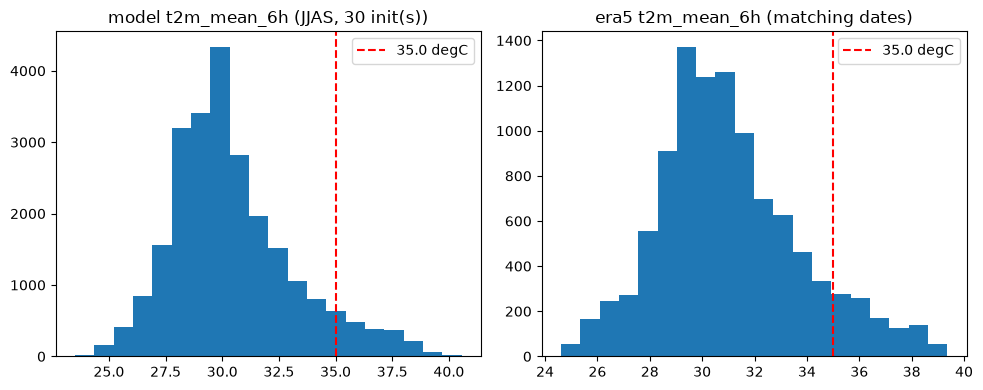

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(model_var_sample.values.flatten(), bins=20)
axes[0].axvline(absolute_threshold, color="red", linestyle="--", label=f"{absolute_threshold} degC")
axes[0].set_title(f"model {variable} (JJAS, {model_sample.sizes['time']} init(s))")
axes[0].legend()
axes[1].hist(era5_var_sample.values.flatten(), bins=20)
axes[1].axvline(absolute_threshold, color="red", linestyle="--", label=f"{absolute_threshold} degC")
axes[1].set_title(f"era5 {variable} (matching dates)")
axes[1].legend()
fig.tight_layout()

## Step 4: Calculate H, M, F, C

`calculate_scores` returns, per initialization batch: unreduced
hit/miss/false-alarm/correct-negative indicators for the absolute threshold
(prefixed `absolute_*`). The `relative_*` branch is commented out for now
(see Step 2's "Local climatology baseline" for how to bring it back
alongside this one) -- RMSE's `squared_error` term is likewise commented
out (uncomment it, and the `rmse_*` lines in Step 5/7, to bring that back
too).

`mean_in_time_batches` reduces only over `"time"` (the initializations),
keeping `prediction_timedelta`, `latitude`, and `longitude` -- i.e. one
global map per lead time, not a single lead-time-averaged map. It processes
one initialization at a time (`batch_size=1`) specifically so the full
multi-year, global, 6-hourly archive never needs to fit in memory at once --
see the earlier discussion of why this batching exists at all.

**Cached to disk** at `by_lead_map_cache_path` after the first run, since
this batching pass is still the expensive part of the notebook even with
climatology skipped. Re-running this cell (or the whole notebook) loads the
cached file instead of recomputing it. To force a fresh recomputation --
e.g. after changing `absolute_threshold`, `variable`, or anything upstream
-- delete that file, or change `by_lead_map_cache_path` in Step 0.

**Timed and logged to `run_timing_log_path`** whenever it actually computes
(not when loading from cache): one row per run recording wall-clock time
alongside the cluster configuration (`n_workers`, `threads_per_worker`,
`memory_limit`) and run parameters, so you can build up a record comparing
configurations over multiple runs rather than a single one-off number.

`prediction_timedelta` is stored as a plain integer lead-day count rather
than relying on `xarray`/`netCDF4`'s `timedelta64` CF encoding: that
round-trip raised `ValueError: failed to prevent overwriting existing key
'dtype' in attrs on variable 'prediction_timedelta'` when actually tested
(xarray 2025.6.1 / netCDF4 1.7.4) -- converting to/from integer days on
either side of `to_netcdf`/`open_dataset` sidesteps it entirely.

In [9]:
def calculate_scores(model_batch: xr.Dataset) -> xr.Dataset:
    # calendar_aligned: bins to lead-day boundaries (0-24h, 24-48h, ...) since
    # initialization, not to whichever step happens to come first in the archive
    # (AIFS-single-v2 has no t+0h step -- see aifs_singlev2.py's docstring for why
    # plain daily_aifs_aggregates()/resample() can't give calendar-aligned bins here).
    model_daily = daily_aifs_aggregates_calendar_aligned(
        model_batch,
        max_days=forecast_days,
    )
    model_var = model_daily[variable]

    # relative_threshold = threshold_at_verification_time(threshold_by_doy, model_var)  # commented out for now

    absolute_indicators = extreme_indicators(model_var, era5_var, absolute_threshold).rename(
        {name: f"absolute_{name}" for name in ("hits", "misses", "false_alarms", "correct_negatives")}
    )
    # relative_indicators = extreme_indicators(model_var, era5_var, relative_threshold).rename(
    #     {name: f"relative_{name}" for name in ("hits", "misses", "false_alarms", "correct_negatives")}
    # )  # commented out for now

    scores = absolute_indicators
    # scores = xr.merge([absolute_indicators, relative_indicators])  # uncomment when relative comes back
    # scores["squared_error"] = squared_error(model_var, era5_var)  # RMSE commented out for now
    return scores.drop_vars("verification_time", errors="ignore")


def log_run_timing(elapsed_seconds: float) -> None:
    """Append one row to run_timing_log_path recording this run's wall-clock
    time alongside the cluster configuration and run parameters, so runs can
    be compared over time (e.g. different regions, year ranges, or n_workers)."""
    row = {
        "timestamp": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "region_label": region_label,
        "test_year_start": test_year_start,
        "test_year_end": test_year_end,
        "n_initializations": model_test_year.sizes["time"],
        "n_lead_days": len(lead_days_to_plot),
        "variable": variable,
        "absolute_threshold": absolute_threshold,
        "n_workers": n_workers,
        "threads_per_worker": threads_per_worker,
        "memory_limit": memory_limit,
        "elapsed_seconds": round(elapsed_seconds, 1),
    }
    write_header = not run_timing_log_path.exists()
    with open(run_timing_log_path, "a", newline="") as log_file:
        writer = csv.DictWriter(log_file, fieldnames=list(row))
        if write_header:
            writer.writeheader()
        writer.writerow(row)
    print(f"Logged run timing to {run_timing_log_path}: {row}")


if by_lead_map_cache_path.exists():
    by_lead_map = xr.open_dataset(by_lead_map_cache_path)
    # Cached prediction_timedelta was saved as plain integer lead-days (see markdown
    # above for why) -- convert back to timedelta64 to match the rest of the notebook.
    by_lead_map = by_lead_map.assign_coords(
        prediction_timedelta=(by_lead_map["prediction_timedelta"].values * np.timedelta64(1, "D")).astype(
            "timedelta64[ns]"
        )
    )
    # Fail loudly here, not later as a cryptic KeyError from .sel(): a cache written
    # by an earlier run with different forecast_days/lead_days_to_plot (e.g. before
    # this config changed, even under the same region_label) can silently be
    # missing a lead day this run wants.
    cached_leads = set(by_lead_map["prediction_timedelta"].values)
    wanted_leads = {np.timedelta64(day, "D").astype("timedelta64[ns]") for day in lead_days_to_plot}
    missing_leads = sorted(wanted_leads - cached_leads)
    if missing_leads:
        raise ValueError(
            f"{by_lead_map_cache_path} is stale: missing lead day(s) {missing_leads} "
            f"(cached file only has {sorted(cached_leads)}). It was likely written by a "
            "run with different forecast_days/lead_days_to_plot. Delete this file "
            "(by_lead_map_cache_path.unlink()) and re-run this cell."
        )
else:
    start_time = time.perf_counter()

    initialization_batch_size = 1
    summaries = mean_in_time_batches(
        model_test_year,
        calculate_scores,
        reductions={"by_lead_map": ("time",)},
        batch_size=initialization_batch_size,
    )
    by_lead_map = summaries["by_lead_map"]

    elapsed_seconds = time.perf_counter() - start_time
    log_run_timing(elapsed_seconds)

    # Save prediction_timedelta as plain integer lead-days, not timedelta64 -- see
    # markdown above for the netCDF encoding error this sidesteps.
    by_lead_map_to_save = by_lead_map.assign_coords(
        prediction_timedelta=(by_lead_map["prediction_timedelta"] / np.timedelta64(1, "D")).astype(int)
    )
    by_lead_map_to_save.to_netcdf(by_lead_map_cache_path)

by_lead_map

/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


Logged run timing to run_timings.csv: {'timestamp': '2026-07-26T22:48:43+00:00', 'region_label': 'region_27.50_29.50_76.50_78.50', 'test_year_start': 2022, 'test_year_end': 2022, 'n_initializations': 91, 'n_lead_days': 5, 'variable': 't2m_mean_6h', 'absolute_threshold': 35.0, 'n_workers': 32, 'threads_per_worker': 1, 'memory_limit': '8GiB', 'elapsed_seconds': 225.0}


<xarray.Dataset> Size: 26kB
Dimensions:                     (latitude: 9, longitude: 9,
                                 prediction_timedelta: 10)
Coordinates:
  * latitude                    (latitude) float64 72B 29.5 29.25 ... 27.75 27.5
  * longitude                   (longitude) float64 72B 76.5 76.75 ... 78.5
  * prediction_timedelta        (prediction_timedelta) timedelta64[ns] 80B 1 ...
Data variables:
    absolute_hits               (prediction_timedelta, latitude, longitude) float64 6kB ...
    absolute_misses             (prediction_timedelta, latitude, longitude) float64 6kB ...
    absolute_false_alarms       (prediction_timedelta, latitude, longitude) float64 6kB ...
    absolute_correct_negatives  (prediction_timedelta, latitude, longitude) float64 6kB ...

## Step 5: Calculate POD, FAR, SEDI

`by_lead_map` holds batch-averaged (not summed) indicators; because these
are means of 0/1 indicators rather than raw counts, the rate functions
(`probability_of_detection`, etc.) give identical results to computing them
from summed contingency counts directly (see `deterministic_metrics.py`'s
module docstring). (RMSE and the relative-threshold lines are commented out
for now -- uncomment along with `squared_error`/`threshold_by_doy` above to
bring them back.)

**Lead-day bins are calendar-aligned** (0-24h, 24-48h, ... since
initialization), via `aifs_singlev2.daily_aifs_aggregates_calendar_aligned`
(see its docstring): AIFS-single-v2 has no t+0h step, so the plain
`resample(...).mean()` used by `daily_aifs_aggregates` anchors bins to
whichever step comes first in the archive -- 6h, 30h, 54h, ... -- not to
lead time zero. `daily_aifs_aggregates_calendar_aligned` bins explicitly via
`floor(step / 1 day) + 1` instead, so `prediction_timedelta` labels land
exactly on `1 days`, `2 days`, `3 days`, .... The `+1` (end-of-window, not
start-of-window) and the calendar alignment itself both match the real
store's own `prediction_timedelta_daily` coordinate -- confirmed directly
against the real AIFS-single-v2 `Dataset` repr, which backs
`total_precipitation`'s daily dimension with exactly this convention
(`N days` = window `[(N-1)*24h, N*24h)`; `2m_temperature` itself is only
stored 6-hourly, so it still needs aggregating here, just consistently with
how precipitation is already labeled in the same store). One caveat this
doesn't remove: **day 1 is a partial bin** (3 of the usual 4 six-hourly
samples -- 6h, 12h, 18h -- since there's no 0h sample to fill the first
slot); every day after that is a complete 4-sample bin.

`select_by_lead_day` below still selects with `method="nearest"` (12-hour
`tolerance`) rather than an exact match, as a defensive fallback -- with
calendar-aligned bins this should always match exactly, but if a lead day is
ever genuinely missing (e.g. a short rollout), this raises a clear error
instead of a silent mismatch.

In [10]:
def finish_event_scores(means: xr.Dataset, prefix: str) -> xr.Dataset:
    """POD/miss-rate/FAR/POFD/SEDI for one threshold definition's indicator means."""
    counts = means[[f"{prefix}_{name}" for name in ("hits", "misses", "false_alarms", "correct_negatives")]]
    counts = counts.rename({f"{prefix}_{name}": name for name in ("hits", "misses", "false_alarms", "correct_negatives")})
    pod = probability_of_detection(counts)
    return xr.Dataset(
        {
            "pod": pod,
            "miss_rate": 1 - pod,
            "far": false_alarm_ratio(counts),
            "pofd": probability_of_false_detection(counts),
            "sedi": symmetric_extremal_dependence_index(counts),
        }
    )


def select_by_lead_day(scores: xr.Dataset, lead_days: list[int]) -> xr.Dataset:
    """Select the nearest available prediction_timedelta bin to each nominal lead
    day, then relabel the coordinate to the clean nominal day (see markdown above:
    with calendar-aligned bins this should always match exactly; nearest+tolerance
    is a defensive fallback, not a fix for a known offset)."""
    lead_timedeltas = np.array(lead_days).astype("timedelta64[D]").astype("timedelta64[ns]")
    selected = scores.sel(
        prediction_timedelta=lead_timedeltas, method="nearest", tolerance=np.timedelta64(12, "h")
    )
    return selected.assign_coords(prediction_timedelta=lead_timedeltas)


# rmse_map = rmse_from_mean_squared_error(by_lead_map["squared_error"]).rename("rmse")  # RMSE commented out for now
absolute_scores = finish_event_scores(by_lead_map, "absolute")
# relative_scores = finish_event_scores(by_lead_map, "relative")  # commented out for now

# rmse_by_lead = select_by_lead_day(rmse_map, lead_days_to_plot)  # RMSE commented out for now
absolute_by_lead = select_by_lead_day(absolute_scores, lead_days_to_plot)
# relative_by_lead = select_by_lead_day(relative_scores, lead_days_to_plot)  # commented out for now

absolute_by_lead

<xarray.Dataset> Size: 16kB
Dimensions:               (latitude: 9, longitude: 9, prediction_timedelta: 5)
Coordinates:
  * latitude              (latitude) float64 72B 29.5 29.25 29.0 ... 27.75 27.5
  * longitude             (longitude) float64 72B 76.5 76.75 77.0 ... 78.25 78.5
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 40B 1 days ....
Data variables:
    pod                   (prediction_timedelta, latitude, longitude) float64 3kB ...
    miss_rate             (prediction_timedelta, latitude, longitude) float64 3kB ...
    far                   (prediction_timedelta, latitude, longitude) float64 3kB ...
    pofd                  (prediction_timedelta, latitude, longitude) float64 3kB ...
    sedi                  (prediction_timedelta, latitude, longitude) float64 3kB ...

## Step 6: Sanity checks

Cheap checks on the results themselves, before reading too much into the
maps in Step 7:

1. **The four categories should sum to ~1** at every valid cell (`by_lead_map`
   holds means of mutually-exclusive, exhaustive 0/1 indicators).
2. **Range check**: POD/FAR/POFD in `[0, 1]`, SEDI in `[-1, 1]`.
3. **Skill should not improve with lead time.** POD/SEDI should trend down
   (or stay flat) from the shortest to the longest lead day plotted, FAR up
   or flat -- a strong reversal is a red flag, not just an odd result.
4. **NaN fraction**: how much of the map is actually defined. If POD/FAR are
   only defined over a tiny sliver, the maps in Step 7 are mostly
   sample-size noise, not signal.

In [11]:
# 1. Four categories sum to ~1
category_total = sum(
    by_lead_map[f"absolute_{name}"] for name in ("hits", "misses", "false_alarms", "correct_negatives")
)
print("category sum -- min:", float(category_total.min()), "max:", float(category_total.max()), "(expect ~1.0, or NaN)")
print()

# 2. Range check
for name in ("pod", "far", "pofd", "sedi"):
    values = absolute_scores[name]
    print(f"{name}: min={float(values.min()):.3f} max={float(values.max()):.3f}")
print()

# 3. Trend across lead days (only informative with more than one lead day plotted)
print("spatial-mean by lead day (days:", lead_days_to_plot, "):")
for name in ("pod", "far", "sedi"):
    means = absolute_by_lead[name].mean(dim=["latitude", "longitude"], skipna=True)
    print(f"  {name}:", [round(float(v), 3) for v in means.values])
print()

# 4. NaN fraction
valid_fraction = absolute_by_lead["pod"].notnull().mean(dim=["latitude", "longitude"])
print("fraction of map with a defined POD, by lead day:", [round(float(v), 3) for v in valid_fraction.values])

category sum -- min: 1.0 max: 1.0 (expect ~1.0, or NaN)

pod: min=0.000 max=1.000
far: min=0.000 max=1.000
pofd: min=0.000 max=0.141
sedi: min=0.419 max=0.969

spatial-mean by lead day (days: [1, 3, 5, 7, 9] ):
  pod: [0.99, 0.448, 0.806, 0.628, 0.438]
  far: [0.547, 0.313, 0.045, 0.248, 0.334]
  sedi: [0.865, 0.845, 0.926, 0.841, 0.849]

fraction of map with a defined POD, by lead day: [1.0, 0.975, 0.975, 0.975, 1.0]


## Step 7: Plotting

One figure for the absolute threshold's POD / FAR / SEDI (3 rows x N lead
days). RMSE's figure and the relative-threshold figure are both commented
out for now (`plot_metric_grid` itself is still defined/used below, just
not called for those two).

Each figure is also saved as a PNG (filename includes `region_label`, so
plots from different regions or year ranges never overwrite each other),
so you have the maps as a persistent file without re-running the notebook.

In [12]:
def plot_metric_grid(
    data_by_row: dict[str, tuple[xr.DataArray, dict]],
    lead_days: list[int],
    suptitle: str,
    region_bounds: tuple[float, float, float, float] | None = None,
):
    """data_by_row: {row_label: (DataArray with a prediction_timedelta dim, plot_kwargs)}.

    region_bounds: (south, north, west, east) -- same convention as
    subset_region(). Pass the notebook's region_bounds here to zoom the map to
    that box instead of the whole globe -- when the data only covers a small
    region, set_global() would draw the entire world with the actual (tiny)
    data patch invisible at that scale. Leave as None for the global run.
    """
    n_rows = len(data_by_row)
    n_cols = len(lead_days)
    figure, axes = plt.subplots(
        nrows=n_rows, ncols=n_cols, figsize=(4 * n_cols, 3 * n_rows),
        subplot_kw={"projection": ccrs.PlateCarree()},
        squeeze=False,
    )
    for row, (row_label, (data, plot_kwargs)) in enumerate(data_by_row.items()):
        for col, lead in enumerate(lead_days):
            axis = axes[row, col]
            lead_timedelta = np.timedelta64(lead, "D")
            data.sel(prediction_timedelta=lead_timedelta).plot(
                ax=axis, x="longitude", y="latitude", transform=ccrs.PlateCarree(),
                add_colorbar=(col == n_cols - 1), cbar_kwargs={"label": row_label} if col == n_cols - 1 else None,
                **plot_kwargs,
            )
            if region_bounds is not None:
                south, north, west, east = region_bounds
                axis.set_extent([west, east, south, north], crs=ccrs.PlateCarree())
            else:
                axis.set_global()
            axis.coastlines(linewidth=0.5)
            axis.set_title(f"{row_label}, lead={lead}d" if row == 0 else f"lead={lead}d")
    figure.suptitle(suptitle)
    figure.tight_layout()
    return figure


# RMSE commented out for now -- uncomment (and the rmse_map/rmse_by_lead lines in Step 5) to bring it back:
# rmse_figure = plot_metric_grid(
#     {"RMSE": (rmse_by_lead, {"cmap": "magma_r", "vmin": 0})},
#     lead_days_to_plot,
#     f"AIFS-single-v2 vs ERA5, {variable}, {test_year_start}-{test_year_end} -- RMSE",
#     region_bounds=region_bounds,
# )
# rmse_figure.savefig(f"aifs_singlev2_rmse_maps_{test_year_start}_{test_year_end}_{region_label}.png", dpi=150)

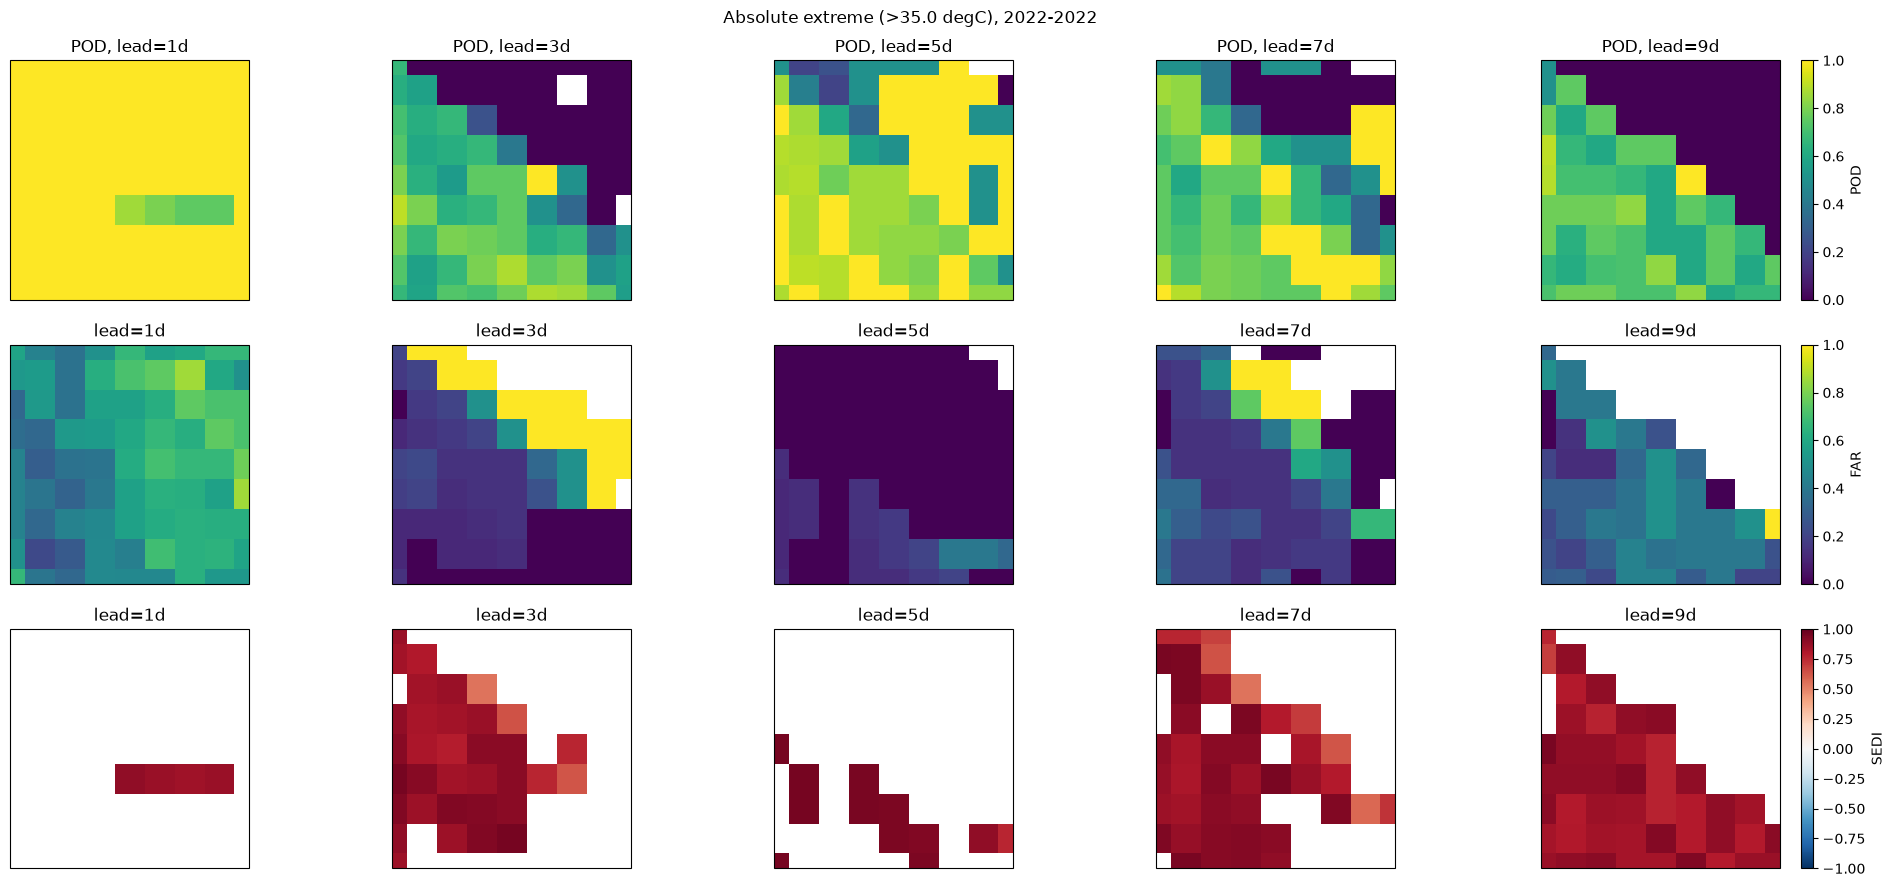

In [13]:
absolute_figure = plot_metric_grid(
    {
        "POD": (absolute_by_lead["pod"], {"cmap": "viridis", "vmin": 0, "vmax": 1}),
        "FAR": (absolute_by_lead["far"], {"cmap": "viridis", "vmin": 0, "vmax": 1}),
        "SEDI": (absolute_by_lead["sedi"], {"cmap": "RdBu_r", "vmin": -1, "vmax": 1}),
    },
    lead_days_to_plot,
    f"Absolute extreme (>{absolute_threshold} degC), {test_year_start}-{test_year_end}",
    region_bounds=region_bounds,
)
absolute_figure.savefig(f"aifs_singlev2_absolute_maps_{test_year_start}_{test_year_end}_{region_label}.png", dpi=150)

In [14]:
# Commented out for now (relative/climatology threshold not active) -- uncomment
# once threshold_by_doy / relative_scores / relative_by_lead are back:
# relative_figure = plot_metric_grid(
#     {
#         "POD": (relative_by_lead["pod"], {"cmap": "viridis", "vmin": 0, "vmax": 1}),
#         "FAR": (relative_by_lead["far"], {"cmap": "viridis", "vmin": 0, "vmax": 1}),
#         "SEDI": (relative_by_lead["sedi"], {"cmap": "RdBu_r", "vmin": -1, "vmax": 1}),
#     },
#     lead_days_to_plot,
#     f"Relative extreme (>{relative_percentile}th %ile of {climatology_start_year}-{climatology_end_year} climatology), {test_year_start}-{test_year_end}",
#     region_bounds=region_bounds,
# )
# relative_figure.savefig(f"aifs_singlev2_relative_maps_{test_year_start}_{test_year_end}_{region_label}.png", dpi=150)